In [1]:
import sys
sys.path.append("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet")
import torch

from settings import base_architecture, num_classes, train_batch_size, train_push_batch_size, img_size, prototype_shape, prototype_activation_function, add_on_layers_type, ablate_prototype_selection
import model
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import joblib


# load dataloader
train_dir = "/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/datasets/nsclc/train_normed_cropped"
train_push_dir = train_dir

train_dataset = datasets.ImageFolder(
    train_dir,
    transforms.Compose([
        transforms.Resize(size=(img_size, img_size)),
        transforms.RandomRotation(degrees=(-180, 180)),
        transforms.ToTensor(),
        # normalize,
    ]))
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=train_batch_size, shuffle=True,
    num_workers=1, pin_memory=False)
# push set
train_push_dataset = datasets.ImageFolder(
    train_push_dir,
    transforms.Compose([
        transforms.Resize(size=(img_size, img_size)),
        transforms.ToTensor(),
    ]))
train_push_loader = torch.utils.data.DataLoader(
    train_push_dataset, batch_size=train_push_batch_size, shuffle=False,
    num_workers=1, pin_memory=False)


In [2]:
from pathlib import Path
import pandas as pd
from tifffile import imread
import anndata

nsclc_path = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed')

mask_path = nsclc_path / 'masks/20250430_cell_masks'
anndata_base_path = nsclc_path / 'export/20250512_adata_graphs'
all_cells_anndata_path = nsclc_path / 'sce_objects/sce.h5ad'
metadata_path = nsclc_path / 'metadata/clinical.parquet'
img_path = nsclc_path / 'images/images_mcd'

df_metadata = pd.read_parquet(metadata_path)
        
def get_mask(patient_id):
    patient_mask_path = mask_path / f"{patient_id}.tiff"
    return imread(patient_mask_path)

def get_anndata(patient_id): 
    return anndata.read_h5ad(anndata_base_path / f'{patient_id}.h5ad')

def get_tumor_type(patient_id):
    return get_anndata(patient_id).obs['DX.name'].iloc[0]

def get_image(patient_id):
    patient_img_path = img_path / f"{patient_id}.tiff"
    return imread(patient_img_path)

In [3]:
import numpy as np

get_kth_prototype_obj = lambda k: joblib.load(f"/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/prototype_results/prototype_{k}.joblib")
get_kth_prototype_obj(5)

bboxes = []

for k in range(20):
    proto_objs = get_kth_prototype_obj(k)
    for proto_obj in proto_objs.values():
        bbox = proto_obj['bbox']
        bboxes.append(bbox)

In [4]:
sample_id = train_push_dataset.samples[k][0].split("/")[-1].split(".")[0]

In [5]:
image_indices = np.random.choice(range(len(train_push_dataset)), size=15, replace=False)
bbox_indices = np.random.choice(range(len(bboxes)), size=15, replace=False)


In [6]:
get_image(sample_id).shape

(43, 833, 798)

In [7]:
top_image_indices = image_indices
masks = {} 
for k in range(len(image_indices)): 
    image_index = image_indices[k]
    image = train_push_dataset[image_index][0]
    bbox_index = bbox_indices[k]
    bbox = bboxes[bbox_index]

    sample_id = train_push_dataset.samples[image_index][0].split("/")[-1].split(".")[0]
    bbox_mask = np.zeros(get_image(sample_id).shape[1:])
    bbox_mask[bbox[0]:bbox[1], bbox[2]:bbox[3]] = 1

    masks[image_index] = bbox_mask

top_image_indices = {"indices": [image_indices]}
masks = [masks]

In [8]:
import push

state_dict_path = "/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/saved_models/resnet152/electric-deluge-9/60_9push0.8037.pth"
ppnet = torch.load(state_dict_path, map_location='cuda', weights_only=False)  # Add map_location if needed
results = push.get_matrix_from_masks(
    masks=masks,
    top_image_indices=top_image_indices,
    prototype_network=ppnet,
    dataloader=train_push_loader,
)


/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1
0 687
Memory usage: RSS 2481.79 MB
0 988
Memory usage: RSS 2649.46 MB
0 913
Memory usage: RSS 2807.21 MB
0 968
Memory usage: RSS 2874.00 MB
0 917
Memory usage: RSS 2974.72 MB
0 817
Memory usage: RSS 3098.06 MB
0 1136
Memory usage: RSS 3161.70 MB
0 245
Memory usage: RSS 3295.75 MB
0 490
Memory usage: RSS 3463.41 MB


: 

: 

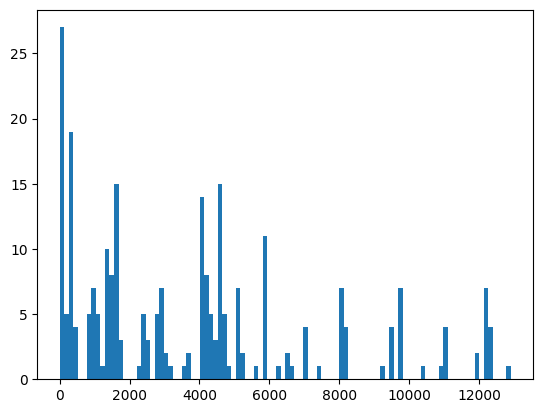

In [25]:
# randomly smaple mask from mask sizes

In [6]:
list(get_kth_prototype_obj(5).values())[0].keys()

dict_keys(['processed_img', 'channel_data', 'original_img', 'mask', 'bbox', 'aggregation_type'])

In [ ]:
for k in 

def get_random_image_stats():
    """
    Gets random 
    """

In [ ]:
def get_random_images_like